# CeNTREX state cleanup — native Rust solver migration

Migrated from the legacy `centrex_tlf_julia_extension` workflow to `centrex-tlf 0.2.5` and its built-in Rust Lindblad solver. Select the **Python (CeNTREX_state_cleanup_new)** kernel. The full scans are expensive; reduce the scan axes while testing.


In [52]:
from importlib.metadata import version
import site
import sys

# Prefer the verified 0.2.5 wheel over this repository checkout when the notebook
# is opened from the source-tree root (which would otherwise shadow site-packages).
sys.path.insert(0, site.getsitepackages()[-1])

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants as cst

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions, utils

print("centrex-tlf", version("centrex-tlf"))

from scripts.scan_hdf import load_scan_hdf, save_scan_hdf

from scripts.scan_progress import grid_scan_with_progress


centrex-tlf 0.2.5


In [53]:
plt.rcParams['axes.titlesize']=24
plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['lines.linewidth']=3
plt.rcParams['legend.fontsize']=20

In [54]:
def doppler_shift(velocity, frequency):
    """calculate the doppler shifted frequency
    Args:
        velocity (float): velocity [m/s]
        frequency (float): frequency [Hz]
    Returns:
        float: doppler shifted frequency in Hz
    """
    return frequency * (1 + velocity / cst.c)


def velocity_to_detuning(velocity, frequency=1.103e15, Γ=2*np.pi*1.56e6):
    """convert velocity to detuning in units of Γ
    Args:
        velocity (float): velocity [m/s]
        frequency (float): frequency [Hz]
        Γ (float): Γ [2π⋅Hz]
    Returns:
        float: detuning in units of Γ
    """
    return (doppler_shift(velocity, frequency) - frequency) * 2 * np.pi / Γ

In [55]:
trans = [transitions.R1_F1_5o2_F2]

polarizations = [[couplings.polarization_X, couplings.polarization_Z]]

transition_selectors = couplings.generate_transition_selectors(
    trans,
    polarizations,
    ground_mains=[
        1 * states.CoupledBasisState(
            J=1, F=2, F1=3 / 2, mF=1, I1=1 / 2, I2=1 / 2,
            Ω=0, P=-1, electronic_state=states.ElectronicState.X,
        )
    ],
    excited_mains=[
        1 * states.CoupledBasisState(
            J=2, F=2, F1=5 / 2, mF=2, I1=1 / 2, I2=1 / 2,
            Ω=1, P=1, electronic_state=states.ElectronicState.B,
        )
    ],
)


In [56]:
def gen_multipass_para(npass, loss, fir_center, dz):
    pow_ord = []
    x_loc = []
    y_loc = []
    pow_para = 1 - loss
    multipas_ord = utils.multipass.multipass_prism_order(npass)
    for i, pass_time in enumerate(multipas_ord):
        x_loc.append(fir_center + i * dz)
        y_loc.append(0.)
        pow_ord.append(pow_para**(pass_time - 1))
    return x_loc, y_loc, pow_ord

xloctions, yloctions, pow = gen_multipass_para(13,0.10,3.5e-3,3.5e-3)
print(pow)

[1.0, 0.31381059609000006, 0.81, 0.3874204890000001, 0.6561, 0.4782969000000001, 0.531441, 0.5904900000000001, 0.4304672100000001, 0.7290000000000001, 0.3486784401000001, 0.9, 0.2824295364810001]


In [57]:
# Experimental/runtime settings. All frequencies are angular frequencies [rad/s].
laser_frequency = 1.103e15  # Hz
vz = 184.0                  # m/s
vx = 0.0                    # m/s
y0_default = 0.0
laser_detuning_default = 20.6 * 2 * np.pi * 1e6
polarization_frequency_default = 0.5 * 2 * np.pi * 1e6
polarization_phase_default = 0.0
power_default = 80e-3       # W

# The old notebook used sigma = diameter / 4 and peak intensity
# P / (2*pi*sigma_x*sigma_y) for each multipass beam.
dz = 0.75e-3 * 4
dy = 12e-3 * 4
sigma_z_default = dz / 4
sigma_y_default = dy / 4
intensities_per_watt = tuple(
    np.asarray(pow, dtype=float) / (2 * np.pi * sigma_z_default * sigma_y_default)
)


In [58]:
%%time
obe_system = lindblad.generate_OBE_system_transitions(
    trans,
    transition_selectors,
    verbose=True,
    qn_compact=True,
    decay_channels=None,
    E=np.array([0.0, 0.0, 150.0]),  # V/cm
    B=np.array([0.0, 0.0, 1e-3]),  # Gauss; resolves +/-mF robustly
    retain_opposite_parity_levels=True,
)


INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 1/5 -> Generating the reduced Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 2/5 -> Generating the couplings corresponding to the transitions
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 3/5 -> Generating the symbolic Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 4/5 -> Generating the collapse matrices
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 5/5 -> Assembling the OBE system (symbolic system of equations is now built lazily on first access)


CPU times: total: 8.38 s
Wall time: 4.43 s


In [59]:
%%time
# Bind the old odeParameters expressions to the new native runtime-parameter graph.
params = lindblad.LindbladParameters()
t = params.time()
laser_power = params.real("laser_power", power_default)
laser_detuning = params.real("laser_detuning", laser_detuning_default)
polarization_frequency = params.real(
    "polarization_frequency", polarization_frequency_default
)
polarization_phase = params.real("polarization_phase", polarization_phase_default)
y0 = params.real("y0", y0_default)
sigma_z = params.real("sigma_z", sigma_z_default)
sigma_y = params.real("sigma_y", sigma_y_default)
intensity_profile = params.real("intensities_per_watt", intensities_per_watt)
xlocs = params.real("xlocs", tuple(xloctions))
ylocs = params.real("ylocs", tuple(yloctions))
main_coupling = params.real(
    "main_coupling", float(abs(obe_system.couplings[0].main_coupling))
)

# multipass_2d_rabi scales as sqrt(intensity), so a unit-power spatial
# profile multiplied by sqrt(laser_power) reproduces the old power scan.
spatial_rabi = lindblad.multipass_2d_rabi(
    vz * t,
    y0,
    intensity_profile,
    xlocs,
    ylocs,
    sigma_z,
    sigma_y,
    main_coupling,
    2.6675506e-30,
)
# No phase EOM is used in the current J=1 cleanup configuration.
drive = laser_power**0.5 * spatial_rabi

doppler_per_mps = float(utils.detuning.velocity_to_detuning(1.0, laser_frequency))
params.bind(
    transition_selectors[0].Ω,
    drive,
    finalize=False,
)
params.bind(
    transition_selectors[0].δ,
    laser_detuning + vx * doppler_per_mps,
    finalize=False,
)

# Old convention: Z polarization when sin(omega*t+phase) >= 0, X otherwise.
px_symbol, pz_symbol = transition_selectors[0].polarization_symbols
pz_gate = lindblad.square_wave(t, polarization_frequency, polarization_phase)
params.bind(px_symbol, 1.0 - pz_gate, finalize=False)
params.bind(pz_symbol, pz_gate, finalize=False)
params._finalize()

prepared = lindblad.prepare_lindblad_problem(
    obe_system,
    params,
    backend="rust",
    hamiltonian_representation="decomposed",
)
print("levels:", len(obe_system.QN))
print("runtime parameters:", params.base_parameters.keys())


levels: 26
runtime parameters: odict_keys(['laser_power', 'laser_detuning', 'polarization_frequency', 'polarization_phase', 'y0', 'sigma_z', 'sigma_y', 'intensities_per_watt', 'xlocs', 'ylocs', 'main_coupling'])
CPU times: total: 500 ms
Wall time: 505 ms


In [60]:
def power_from_rabi_rectangle(Ω: complex, main_coupling: complex, dx: float, dy: float, D: float = 2.6675506e-30) -> float:
    E = Ω*cst.hbar / (main_coupling * D)
    intensity = 1/2 * cst.c * cst.epsilon_0 * E ** 2
    P = intensity * (dx * dy)
    return P.real

def rabi_from_power_gaussian(power: float, main_coupling: complex, dx: float, dy: float, D: float = 2.6675506e-30) -> complex:
    intensity = 2 * power / (np.pi* dx * dy)
    E = np.sqrt(intensity*2 / (cst.c * cst.epsilon_0))
    Ω = E * main_coupling * D / cst.hbar
    return Ω

def rabi_from_power_rectangle(power: float, main_coupling: complex, dx: float, dy: float, D: float = 2.6675506e-30) -> complex:
    intensity = power / (dx * dy)
    E = np.sqrt(intensity*2 / (cst.c * cst.epsilon_0))
    Ω = E * main_coupling * D / cst.hbar
    return Ω

def peak_gaussian_intensity(power, dx, dy) -> float:
    intensity = power / (dx * dy)
    return intensity

In [61]:
print(np.abs(obe_system.couplings[0].main_coupling))

0.10035762728394393


In [62]:
print("sigma_z [m] =", sigma_z_default)
print("sigma_y [m] =", sigma_y_default)
print("laser power [mW] =", power_default * 1e3)
print("main coupling =", abs(obe_system.couplings[0].main_coupling))


sigma_z [m] = 0.00075
sigma_y [m] = 0.012
laser power [mW] = 80.0
main coupling = 0.10035762728394393


In [63]:
couplings.generate_br_dataframe(obe_system.ground, obe_system.excited,group_ground='J')

,"|B, J = 2, F1 = 5/2, F = 2>"
states,
"|X, J = 0>",0.000042
"|X, J = 1>",0.262561
"|X, J = 2>",0.473165
"|X, J = 3>",0.237541
"|X, J = 4>",0.026691


In [64]:
qn_select = states.QuantumSelector(J=1, electronic=states.ElectronicState.X)
ground_idx = np.asarray(qn_select.get_indices(obe_system.QN), dtype=int).ravel()
rho0 = np.zeros(obe_system.H_symbolic.shape, dtype=np.complex128)
rho0[ground_idx, ground_idx] = 1.0 / ground_idx.size
print("initial states:", ground_idx.size, "trace:", np.trace(rho0).real)


initial states: 12 trace: 1.0


In [65]:
t_end = 0.05 / vz
saveat = np.append(np.arange(0.0, t_end, 1e-6), t_end)
solver_options = dict(
    solver="dopri5",
    execution_mode="expanded_sparse",
    dt=2e-9,
    reltol=1e-7,
    abstol=1e-9,
    maxiters=500_000,
)


In [66]:
results = lindblad.solve_lindblad(
    prepared,
    rho0,
    (0.0, t_end),
    saveat=saveat,
    output="populations",
    output_when="saveat",
    **solver_options,
)
populations = results.values


In [67]:
qn_select_excited = states.QuantumSelector(electronic=states.ElectronicState.B)
excited_idx = np.asarray(qn_select_excited.get_indices(obe_system.QN), dtype=int).ravel()

nT, nS = populations.shape
print("number of time bins =", nT)
print("number of states =", nS)
print("final total population =", populations[-1].sum())


number of time bins = 273
number of states = 26
final total population = 0.9999999999999962


In [68]:
# J1_idx = states.QuantumSelector(J=1,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J0_idx = states.QuantumSelector(J=0,electronic=states.ElectronicState.X).get_indices(obe_system.QN)

J1_others_idx = []
for stuff in states.QuantumSelector(J=1,electronic=states.ElectronicState.X).get_indices(obe_system.QN):
    if stuff not in ground_idx:
        J1_others_idx.append(stuff)
J2_idx = states.QuantumSelector(J=2,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
# J2_others_idx = np.array(J2_others_idx)
J3_idx = states.QuantumSelector(J=3,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J4_idx = states.QuantumSelector(J=4,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J5_idx = states.QuantumSelector(J=5,electronic=states.ElectronicState.X).get_indices(obe_system.QN)

state clean up efficiency = 0.9989355353329177
photons per molecule = 1.2731726381293527


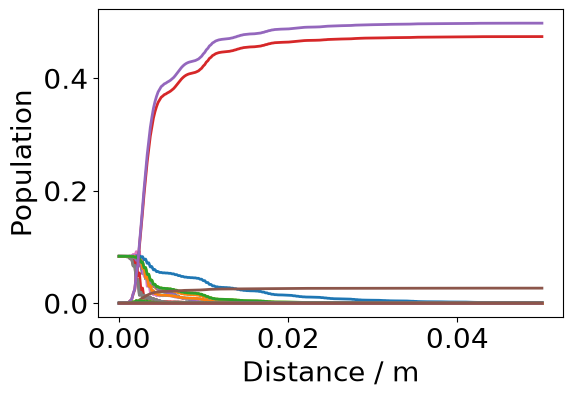

In [69]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(results.t * vz, populations, lw=2)
ax.set_xlabel("Distance / m")
ax.set_ylabel("Population")

clean_up_eff = np.sum(populations[-1, ground_idx])
nphotons = np.trapezoid(populations[:, excited_idx].sum(axis=1), x=results.t) * hamiltonian.Γ
print("state clean up efficiency =", 1 - clean_up_eff)
print("photons per molecule =", nphotons)


In [70]:
ground_final = []
for idx in ground_idx:
    state_label = obe_system.QN[idx].largest
    ax.plot(results.t * vz, populations[:, idx], lw=2, label=str(state_label))
    ground_final.append(populations[:, idx])


remainder in ground state = 0.001064464667082296
remainder in J=0 = [7.73065837e-05]
remainder in J=1, other state = 0.0
remainder in J=2 = [0.47413603]
remainder in J=3 = [0.49799788]
remainder in J=4 = [0.02672432]
remainder in J=5 = []


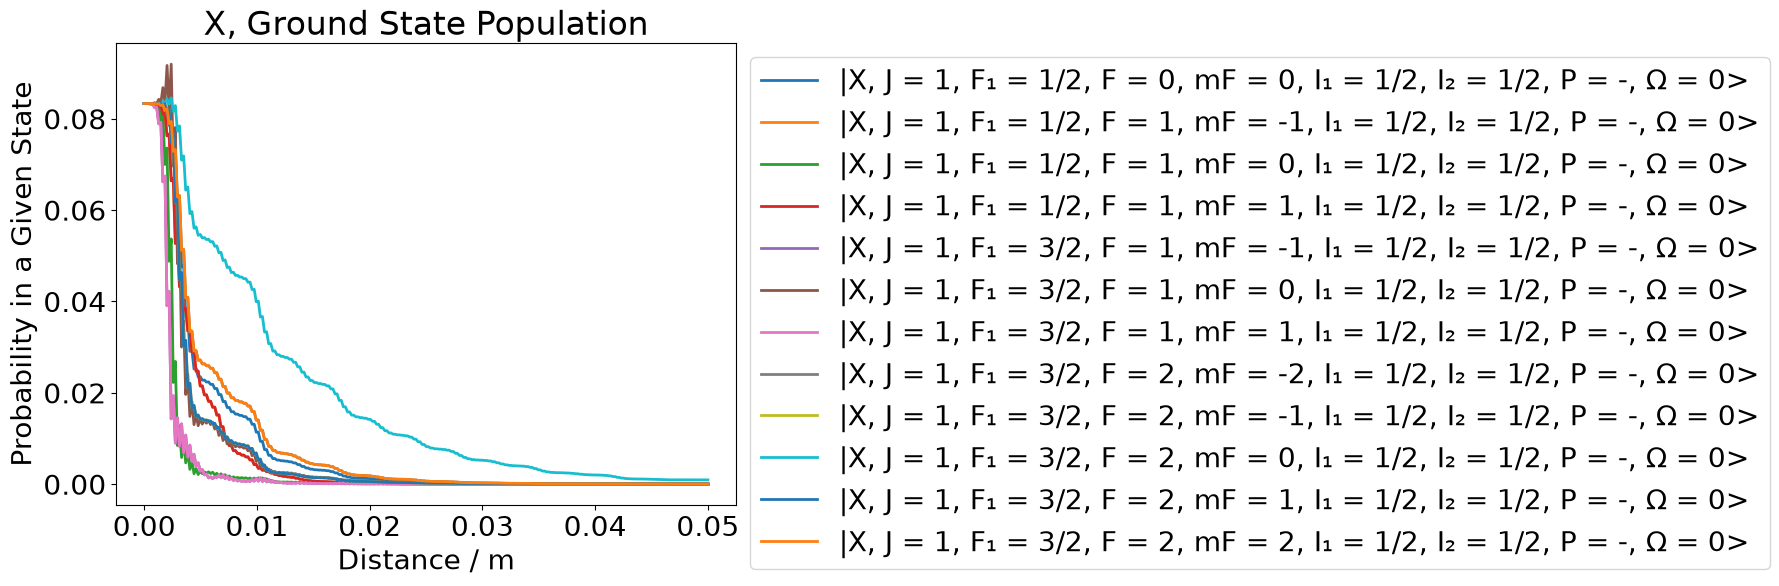

In [71]:
fig, ax = plt.subplots(figsize=(8, 6))

stop_dist = 0.05
stop = np.argmin(abs(results.t - stop_dist / vz))

ground_final = []
for idx in ground_idx:
    state_label = obe_system.QN[idx].largest
    ax.plot(results.t * vz, populations[:, idx], lw=2, label=str(state_label))
    ground_final.append(populations[-1, idx])
ax.set_title("X, Ground State Population")
ax.set_ylabel("Probability in a Given State")
ax.set_xlabel("Distance / m")
ax.legend(bbox_to_anchor=[1, 1])

print("remainder in ground state =", np.sum(ground_final))
print("remainder in J=0 =", populations[stop, J0_idx])
print("remainder in J=1, other state =", np.sum(populations[stop, J1_others_idx]))
print("remainder in J=2 =", populations[stop, J2_idx])
print("remainder in J=3 =", populations[stop, J3_idx])
print("remainder in J=4 =", populations[stop, J4_idx])
print("remainder in J=5 =", populations[stop, J5_idx])


## Structured parameter scans

All scan results below are the **final population remaining in the initial J=1 manifold**. Therefore `cleanup_efficiency = 1 - remaining_population`.

The array dimensions always follow the insertion order of `scan_axes`. HDF5 stores that order, every axis and unit, fixed experimental conditions, model construction settings, solver tolerances, and the package version. Frequencies are converted to MHz before storage for readability.

In [72]:
scan_solver_options = dict(
    solver="dopri5",
    execution_mode="expanded_sparse",
    output="populations",
    output_when="final",
    dt=2e-9,
    reltol=1e-7,
    abstol=1e-9,
    maxiters=500_000,
    parallel=True,
)

model_metadata = {
    "notebook": "SPB_cleanup_J1-J2F2.ipynb",
    "centrex_tlf_version": version("centrex-tlf"),
    "transition": str(trans[0]),
    "retain_opposite_parity_levels": True,
    "number_of_levels": len(obe_system.QN),
    "initial_manifold": "X, J=1, uniform population",
    "initial_state_count": int(ground_idx.size),
}

fixed_conditions = {
    "electric_field_V_per_cm": [0.0, 0.0, 150.0],
    "magnetic_field_G": [0.0, 0.0, 1e-3],
    "interaction_length_m": 0.05,
    "molecular_vz_m_per_s": vz,
    "molecular_vx_m_per_s": vx,
    "laser_frequency_Hz": laser_frequency,
    "phase_EOM_used": False,
    "polarization_switch_frequency_MHz": polarization_frequency_default/(2*np.pi*1e6),
    "sigma_z_mm": sigma_z_default*1e3,
    "sigma_y_mm": sigma_y_default*1e3,
    "multipass_count": len(xloctions),
    "multipass_relative_power": list(pow),
    "main_coupling": float(abs(obe_system.couplings[0].main_coupling)),
}


### Power × carrier-detuning scan

The current J=1 cleanup configuration does not use a phase EOM. This scan therefore varies only optical power and carrier placement. The stored result has dimensions `[power, detuning]`; no transpose is applied.

In [76]:
# Use coarse axes for testing; increase the point counts for the final production scan.
power_mW = np.linspace(10.0, 110.0, 6)
detuning_MHz = np.linspace(-16.0, 30.0, 46)

scan_axes = {
    "laser_power": power_mW*1e-3,
    "laser_detuning": detuning_MHz*2*np.pi*1e6,
}

frequency_scan = grid_scan_with_progress(
    prepared, rho0, (0.0, t_end), scan=scan_axes, **scan_solver_options
    , chunk_size=32, description="J=1 power/detuning"
)
frequency_populations = frequency_scan.values.reshape(
    len(power_mW), len(detuning_MHz), len(obe_system.QN)
)
frequency_remaining = frequency_populations[..., ground_idx].sum(axis=-1).real
frequency_cleanup = 1.0-frequency_remaining
print("remaining-population shape [power, detuning] =", frequency_remaining.shape)


J=1 power/detuning: 100%|██████████| 276/276 [06:55<00:00,  1.51s/trajectory]

remaining-population shape [power, detuning] = (6, 46)


In [78]:
frequency_file = save_scan_hdf(
    "SPB_J1_cleanup_scans.h5",
    "power_detuning_no_phase_eom",
    frequency_remaining,
    axes={
        "laser_power_mW": (power_mW, "mW"),
        "laser_detuning_MHz": (detuning_MHz, "MHz"),
    },
    quantity="final_population_remaining_in_X_J1",
    fixed_parameters=fixed_conditions,
    model=model_metadata,
    solver=scan_solver_options,
    notes="Uniform initial population over all retained X,J=1 states.",
    overwrite=True,  # Protect an existing long-running scan; change run_name for a new run.
)
print("saved:", frequency_file)


saved: C:\Users\16612\OneDrive\Documents\GitHub\CeNTREX_state_cleanup_new\SPB_J1_cleanup_scans.h5


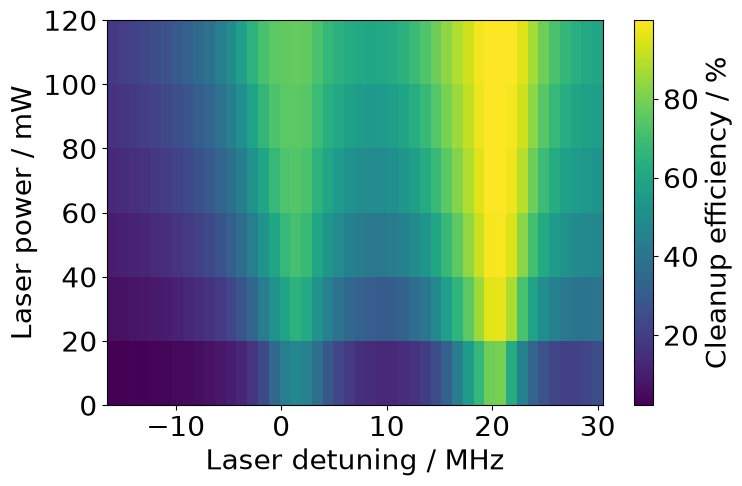

In [80]:
fig, ax = plt.subplots(figsize=(8, 5))
mesh = ax.pcolormesh(
    detuning_MHz, power_mW, 100*frequency_cleanup, shading="auto"
)
fig.colorbar(mesh, ax=ax, label="Cleanup efficiency / %")
ax.set(xlabel="Laser detuning / MHz", ylabel="Laser power / mW")
plt.show()


### Vertical position × beam diameter scan

The runtime parameter is Gaussian `sigma_y`, while the experimental scan axis is the quoted full diameter `4*sigma_y`. The HDF5 file stores the diameter in mm and documents this conversion.

In [ ]:
y_position_mm = np.linspace(-12.0, 12.0, 50)
beam_diameter_mm = np.linspace(10.0, 50.0, 5)

geometry_scan = grid_scan_with_progress(
    prepared, rho0, (0.0, t_end),
    scan={
        "y0": y_position_mm*1e-3,
        "sigma_y": beam_diameter_mm*1e-3/4.0,
    },
    **scan_solver_options,
    chunk_size=32,
    description="J=1 beam geometry",
)
geometry_populations = geometry_scan.values.reshape(
    len(y_position_mm), len(beam_diameter_mm), len(obe_system.QN)
)
# Preserve scan-axis order: [vertical position, beam diameter].
geometry_remaining = geometry_populations[..., ground_idx].sum(axis=-1).real
geometry_cleanup = 1.0-geometry_remaining
print("remaining-population shape [y position, beam diameter] =", geometry_remaining.shape)


In [ ]:
geometry_file = save_scan_hdf(
    "SPB_J1_cleanup_scans.h5",
    "vertical_position_beam_diameter",
    geometry_remaining,
    axes={
        "vertical_position_mm": (y_position_mm, "mm"),
        "beam_diameter_4sigma_mm": (beam_diameter_mm, "mm"),
    },
    quantity="final_population_remaining_in_X_J1",
    fixed_parameters={
        **fixed_conditions,
        "laser_power_mW": power_default*1e3,
        "carrier_detuning_MHz": laser_detuning_default/(2*np.pi*1e6),
        "phase_EOM_used": False,
    },
    model=model_metadata,
    solver=scan_solver_options,
    notes="beam_diameter_4sigma_mm is converted to runtime sigma_y by sigma_y=diameter/4.",
    overwrite=False,  # Protect an existing long-running scan; change run_name for a new run.
)
print("saved:", geometry_file)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
mesh = ax.pcolormesh(
    beam_diameter_mm, y_position_mm, 100*geometry_cleanup, shading="auto"
)
fig.colorbar(mesh, ax=ax, label="Cleanup efficiency / %")
ax.set(xlabel="Beam diameter (4σ) / mm", ylabel="Vertical position / mm")
plt.show()


### HDF5 readback example

Loading does not require recreating the OBE system. It returns the result, axes, units, fixed conditions, model information and solver settings together.

In [ ]:
saved_run = load_scan_hdf("SPB_J1_cleanup_scans.h5", "power_detuning_no_phase_eom")
print(saved_run["results"].shape)
print(saved_run["units"])
print(saved_run["fixed_parameters"])
